## Retail Demand Forecasting & Inventory Planning


Objective

This project analyses historical retail sales data to identify demand trends, seasonal patterns, and forecast future demand to support inventory planning decisions.

## 1. Business Problem


Retail companies must accurately forecast product demand to avoid stock shortages and excess inventory. Understanding demand patterns helps companies optimise inventory levels and improve supply chain efficiency.

## 2.Data Description


The dataset used in this project is the Walmart Store Sales dataset. It contains historical sales information including store number, department, weekly sales, and holiday indicators.




## 3. Data Preparation


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("train.csv")

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Month         421570 non-null  int32         
dtypes: bool(1), datetime64[ns](1), float64(1), int32(1), int64(2)
memory usage: 14.9 MB


## 4. Exploratory Data Analysis

### 4.1 Overall Sales Trend

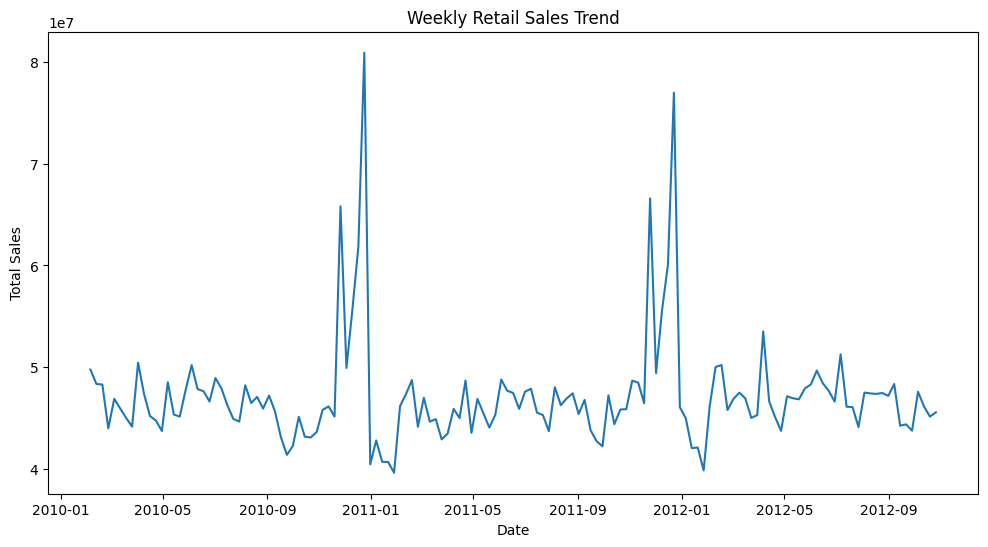

In [7]:
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12,6))
plt.plot(weekly_sales)
plt.title("Weekly Retail Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

INTERPRETATION:
The weekly retail sales trend shows fluctuations in sales over time, with several noticeable spikes. These spikes indicate periods of significantly higher demand, which may be associated with major retail events or holiday shopping seasons. Apart from these peak periods, sales remain relatively stable with moderate variation. This suggests that while baseline demand is consistent, certain weeks experience substantial increases in customer purchasing activity.

### 4.2 Seasonal Pattern Analysis

In [8]:
df['Month'] = df['Date'].dt.month

In [9]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

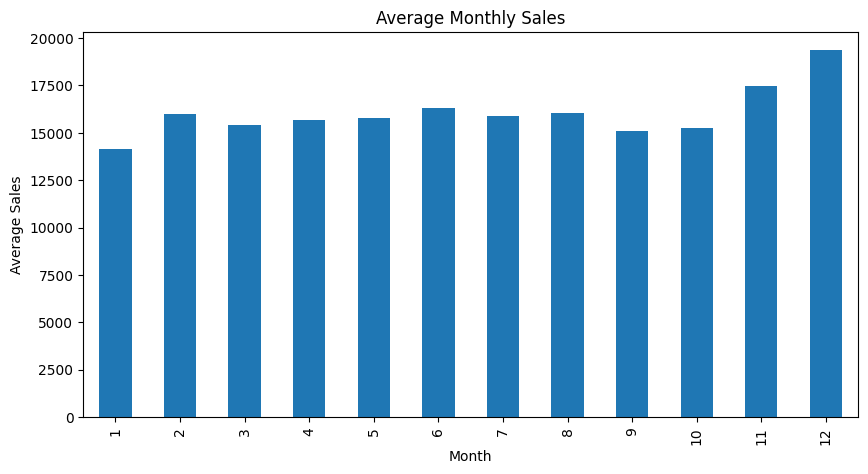

In [10]:
monthly_sales.plot(kind='bar', figsize=(10,5))
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

INTERPRETATION:
The average monthly sales chart shows that demand varies across different months of the year. Sales appear to increase towards the end of the year, particularly in November and December. This pattern suggests a seasonal demand cycle, where consumer spending increases during the holiday shopping season. Retailers can use this insight to adjust inventory levels in advance of high-demand months.

### 4.3 Holiday Demand Analysis

In [11]:
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()

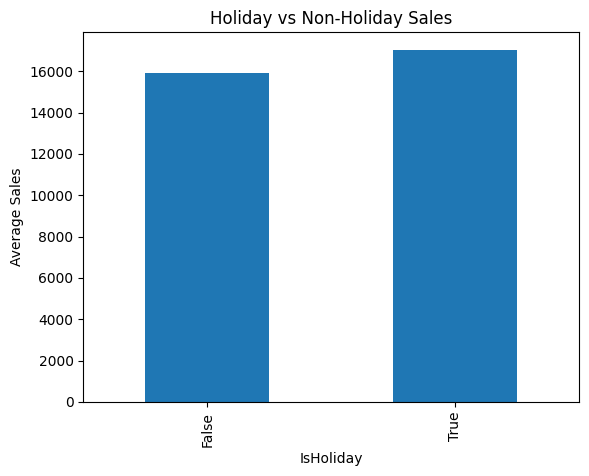

In [12]:
holiday_sales.plot(kind='bar')
plt.title("Holiday vs Non-Holiday Sales")
plt.ylabel("Average Sales")
plt.show()

INTERPRETATION:
The comparison between holiday and non-holiday sales indicates that average sales during holiday weeks are higher than during non-holiday weeks. This suggests that holidays have a noticeable impact on consumer purchasing behaviour. Retailers may need to increase stock availability and prepare supply chains ahead of these periods to meet increased demand.

### 4.4 Store Performance Analysis

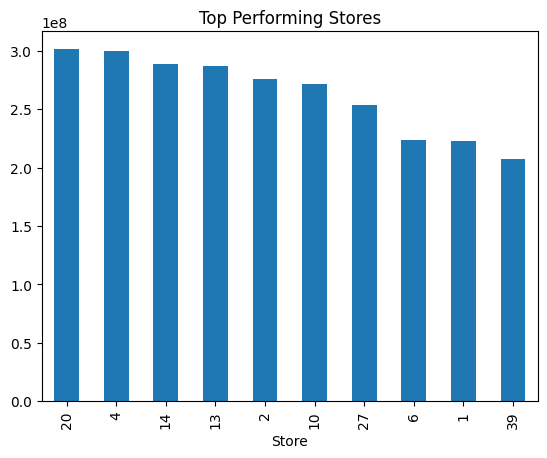

In [15]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

store_sales.head(10).plot(kind='bar')
plt.title("Top Performing Stores")
plt.show()

INTERPRETATION: The chart of top-performing stores shows that some stores generate significantly higher total sales compared to others. This indicates that sales performance varies across store locations, possibly due to differences in customer traffic, store size, or regional demand. Retailers could prioritise inventory distribution and promotional efforts in high-performing stores to maximise revenue.

## 5. Demand Forecasting

In [16]:
!pip install prophet

In [17]:
from prophet import Prophet

In [19]:
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

In [20]:
forecast_df = weekly_sales.rename(columns={
    'Date': 'ds',
    'Weekly_Sales': 'y'
})

In [21]:
forecast_df.head()

,ds,y
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


The dataset was prepared for the forecasting model by renaming the columns to match the required format. The ds column represents the date, while y represents the total weekly sales. This structure allows the forecasting model to analyse historical sales patterns and generate future demand predictions.

In [22]:
model = Prophet()
model.fit(forecast_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [23]:
future = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

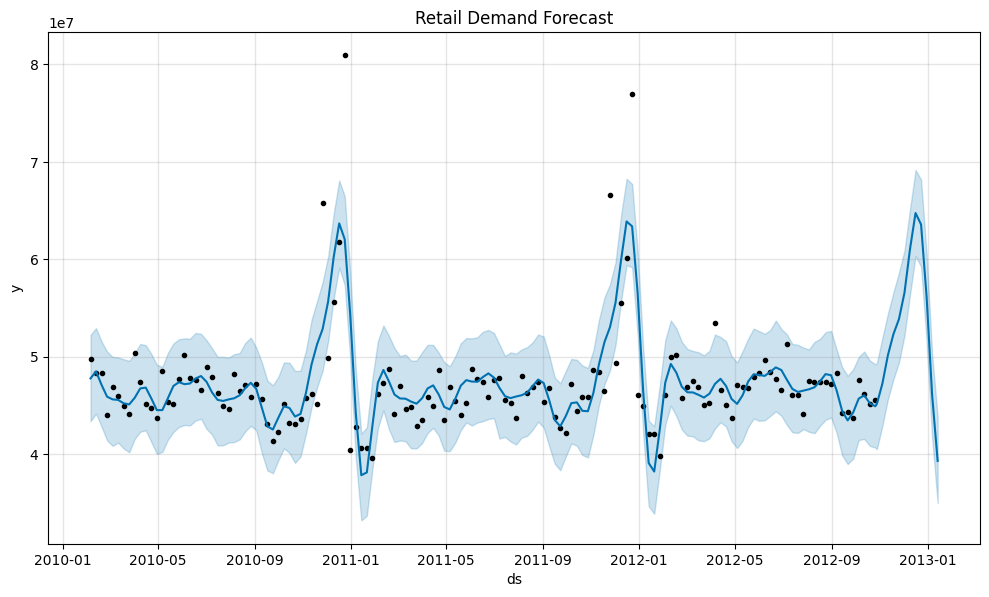

In [25]:
fig = model.plot(forecast)
plt.title("Retail Demand Forecast")
plt.show()

INTERPRETATION:
The demand forecast chart shows predicted future sales based on historical sales patterns. The model captures both the overall trend and fluctuations in demand. The shaded region represents the uncertainty range of the forecast, indicating possible variations in future demand. This type of forecasting can help retailers anticipate demand changes and make more informed inventory planning decisions.

In [26]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
150,2012-12-16,6.475042e+07,6.034440e+07,6.916780e+07
151,2012-12-23,6.357694e+07,5.924768e+07,6.818374e+07
152,2012-12-30,5.616149e+07,5.157011e+07,6.056159e+07
153,2013-01-06,4.607705e+07,4.169552e+07,5.026008e+07
154,2013-01-13,3.929397e+07,3.497726e+07,4.383679e+07


The forecast output shows the predicted sales values for future dates. The yhat column represents the predicted sales, while yhat_lower and yhat_upper indicate the lower and upper bounds of the prediction interval. These bounds represent the uncertainty in the forecast and provide a range within which future demand is likely to fall.

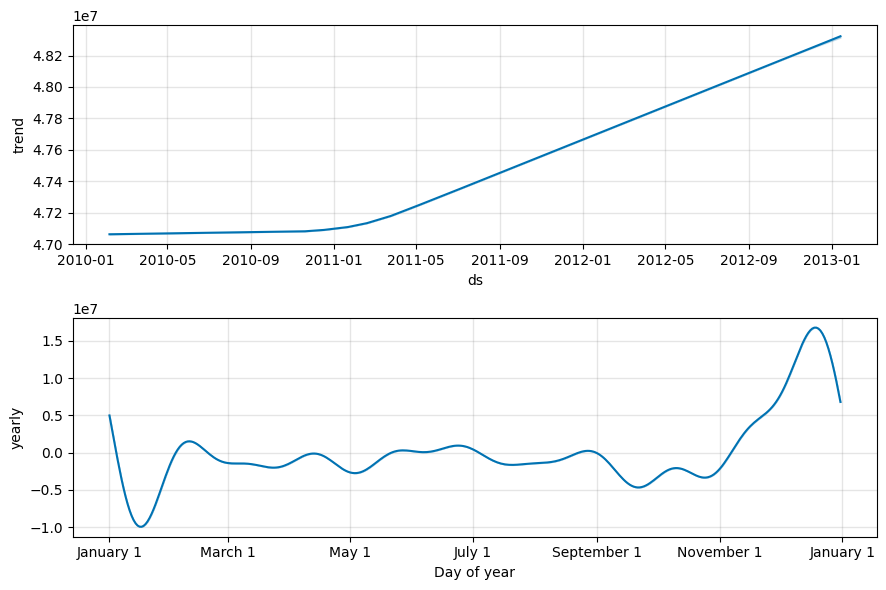

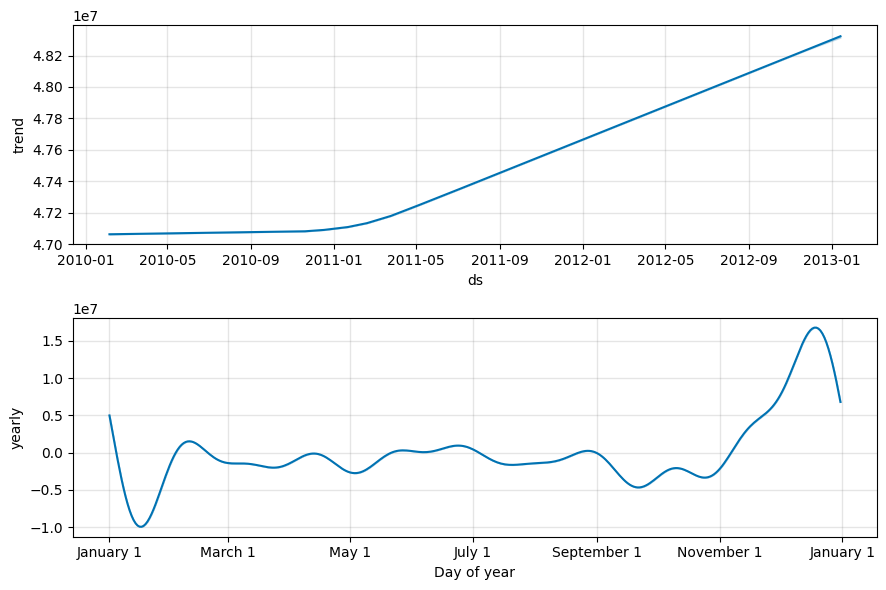

In [27]:
model.plot_components(forecast)

INTERPRETATION:
The trend component indicates a gradual increase in overall retail demand over time. The seasonal component reveals recurring patterns throughout the year, with certain periods showing higher expected sales than others. These seasonal patterns suggest that demand is influenced by predictable events such as holiday shopping periods, allowing retailers to plan inventory and staffing more effectively.

## 6. Business Insights

- Retail sales show noticeable fluctuations across weeks, with certain periods experiencing significant spikes in demand.

- Monthly sales analysis indicates seasonal patterns, with higher sales towards the end of the year, suggesting increased consumer spending during holiday shopping periods.

- Sales during holiday weeks tend to be higher than non-holiday weeks, highlighting the importance of holiday demand in retail planning.

- Some stores consistently generate higher sales than others, suggesting differences in customer traffic or regional demand.

- The forecasting model predicts future sales trends based on historical patterns, which can help retailers anticipate demand changes.

## 7. Conclusion

This project analysed Walmart retail sales data to understand demand patterns and forecast future sales. The analysis revealed clear seasonal variations in sales, with higher demand during holiday periods and at the end of the year. Store-level analysis also showed that certain stores contribute more significantly to total sales. Using historical sales data, the forecasting model was able to predict future demand trends. These insights can support retailers in improving inventory planning and supply chain decision-making.